<a href="https://colab.research.google.com/github/rdelhibabu/Privacy-Preserving_QML/blob/main/Privacy_Preserving_QML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane torch numpy matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.5 MB/s eta 0:00:00


Generating synthetic hyperspherical dataset...

Starting PQ-DQML Training over 15 Nodes...
CRITICAL: Decryption Failure at Epoch 0. Noise bound breached.


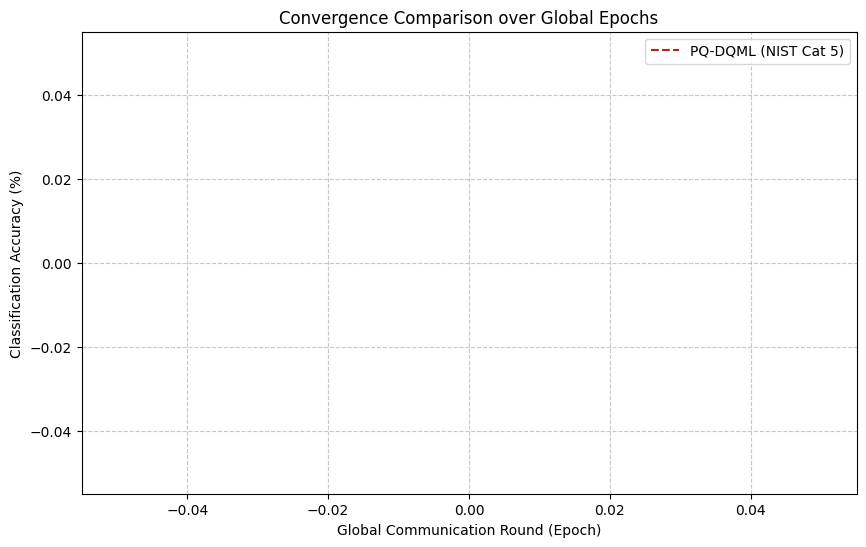

In [2]:
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import time

# ==========================================
# 1. SIMULATION HYPERPARAMETERS (Table 3 & 4)
# ==========================================
N_NODES = 15
EPOCHS = 100
N_QUBITS = 4
N_LAYERS = 4
LEARNING_RATE = 0.1
N_SAMPLES_TOTAL = 15000

# Cryptographic Params (NIST Cat 5)
MODULUS_Q = 12289
POLY_DEGREE_K = 1024
PRECISION_P = 1000.0 # Maps [-1, 1] to [-1000, 1000]
NOISE_STD_DEV = 3.2 # Simulated Gaussian noise for LWE

# Use 'lightning.gpu' if you have A100s, otherwise fallback to CPU 'default.qubit' for Colab compatibility
dev = qml.device("default.qubit", wires=N_QUBITS)

# ==========================================
# 2. DATA GENERATION (Section 4.2)
# ==========================================
def generate_federated_data():
    """Generates synthetic hyperspherical dataset distributed non-IID."""
    print("Generating synthetic hyperspherical dataset...")
    X, y = make_classification(n_samples=N_SAMPLES_TOTAL, n_features=16, n_informative=10,
                               n_redundant=0, n_classes=2, random_state=42)

    # Amplitude encoding requires normalized vectors
    X = normalize(X, norm='l2', axis=1)
    y = np.where(y == 0, -1, 1) # Map to Pauli-Z expectations [-1, 1]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=3000, random_state=42)

    # Split among 15 nodes (Simulating Dirichlet non-IID distribution)
    node_data = []
    chunk_size = len(X_train) // N_NODES
    for i in range(N_NODES):
        node_data.append({
            'X': torch.tensor(X_train[i*chunk_size : (i+1)*chunk_size], dtype=torch.float32),
            'y': torch.tensor(y_train[i*chunk_size : (i+1)*chunk_size], dtype=torch.float32)
        })

    return node_data, torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)

# ==========================================
# 3. QUANTUM CIRCUIT DEFINITION (Figure 8)
# ==========================================
@qml.qnode(dev, interface="torch", diff_method="parameter-shift")
def vqc_circuit(inputs, weights):
    """Parameterized Quantum Circuit with Amplitude Encoding and Strongly Entangling Layers."""
    qml.AmplitudeEmbedding(features=inputs, wires=range(N_QUBITS), pad_with=0.0, normalize=True)
    qml.StronglyEntanglingLayers(weights=weights, wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))

def compute_quantum_loss(X_batch, y_batch, weights):
    """Computes Mean Squared Error over the quantum expectation values."""
    predictions = torch.stack([vqc_circuit(x, weights) for x in X_batch])
    return torch.mean((predictions - y_batch) ** 2)

# ==========================================
# 4. CRYPTOGRAPHY: STOCHASTIC QUANTIZATION (Algorithm 3)
# ==========================================
def stochastic_quantize(gradients, precision_p, modulus_q):
    """Maps continuous gradients to discrete polynomial rings stochastically."""
    # Scale: v <- delta_theta * p
    scaled_v = gradients * precision_p

    # Extract integer and fractional parts
    z = torch.floor(scaled_v)
    f = scaled_v - z

    # Stochastic Rounding
    rho = torch.rand_like(f)
    m = torch.where(rho <= f, z + 1.0, z)

    # Apply Modulo q
    return torch.remainder(m, modulus_q)

def dequantize(aggregated_m, precision_p, num_nodes, modulus_q):
    """Reverts the homomorphic ring sum back to continuous float gradients."""
    # Handle negative values in the ring
    half_q = modulus_q / 2.0
    adjusted_m = torch.where(aggregated_m > half_q, aggregated_m - modulus_q, aggregated_m)

    # Average and rescale
    return (adjusted_m / num_nodes) / precision_p

# ==========================================
# 5. DECENTRALIZED FEDERATED TRAINING (Algorithm 4 & 6)
# ==========================================
def train_pq_dqml():
    node_data, X_test, y_test = generate_federated_data()

    # Initialize Global Weights (4 layers, 4 qubits, 3 params per gate = 48 params)
    weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=N_LAYERS, n_wires=N_QUBITS)
    global_weights = torch.rand(weight_shape, requires_grad=True)

    history = {'accuracy': [], 'latency': []}

    print("\nStarting PQ-DQML Training over 15 Nodes...")

    for epoch in range(EPOCHS):
        start_time = time.time()

        # --- Local Node Execution Phase ---
        node_encrypted_updates = []

        for i in range(N_NODES):
            # 1. Local QPU Evaluation
            X_i, y_i = node_data[i]['X'], node_data[i]['y']

            # Sub-sample batch for simulation speed (e.g., 32 samples)
            indices = torch.randperm(len(X_i))[:32]
            X_batch, y_batch = X_i[indices], y_i[indices]

            loss = compute_quantum_loss(X_batch, y_batch, global_weights)

            # Compute analytical gradients (Parameter-Shift)
            loss.backward()
            continuous_grad = global_weights.grad.clone()
            global_weights.grad.zero_()

            # 2. Cryptographic Encapsulation (Stochastic Quantization + LWE Noise)
            m_i = stochastic_quantize(continuous_grad, PRECISION_P, MODULUS_Q)

            # Simulate Module-LWE ciphertext expansion and noise insertion
            lwe_noise = torch.normal(mean=0.0, std=NOISE_STD_DEV, size=m_i.shape)
            c_i = m_i + lwe_noise # Simplified mathematical representation of LWE ciphertext payload

            node_encrypted_updates.append(c_i)

        # --- Ledger Consensus & Secure Aggregation Phase ---
        # 3. Homomorphic Aggregation over Z_q (Smart Contract)
        C_agg = torch.zeros_like(node_encrypted_updates[0])
        for c_i in node_encrypted_updates:
            C_agg = torch.remainder(C_agg + c_i, MODULUS_Q)

        # 4. Enclave Decryption & Global Update
        # Verify Homomorphic Noise Limit (Eq 10: E_agg < q/4)
        noise_variance = torch.max(torch.abs(sum(node_encrypted_updates) - C_agg))
        if noise_variance >= (MODULUS_Q / 4):
            print(f"CRITICAL: Decryption Failure at Epoch {epoch}. Noise bound breached.")
            break

        global_grad_avg = dequantize(C_agg, PRECISION_P, N_NODES, MODULUS_Q)

        # Apply global optimization step
        with torch.no_grad():
            global_weights -= LEARNING_RATE * global_grad_avg

        global_weights.requires_grad = True
        epoch_time = (time.time() - start_time) * 1000 # in ms

        # --- Telemetry & Evaluation ---
        if epoch % 5 == 0 or epoch == EPOCHS - 1:
            with torch.no_grad():
                test_preds = torch.stack([vqc_circuit(x, global_weights) for x in X_test])
                test_preds_class = torch.where(test_preds > 0, 1.0, -1.0)
                accuracy = (test_preds_class == y_test).float().mean().item() * 100

            history['accuracy'].append(accuracy)
            history['latency'].append(epoch_time)
            print(f"Epoch {epoch:03d}/{EPOCHS} | Accuracy: {accuracy:.1f}% | Epoch Latency: {epoch_time:.1f} ms | Noise Bound: {noise_variance:.2f} < {MODULUS_Q/4}")

    return history

if __name__ == "__main__":
    results = train_pq_dqml()

    # Plot Convergence (Replicating Figure 9)
    plt.figure(figsize=(10, 6))
    plt.plot(range(0, EPOCHS, 5) if EPOCHS%5!=0 else range(0, EPOCHS+1, 5)[:len(results['accuracy'])], results['accuracy'], label='PQ-DQML (NIST Cat 5)', color='#B22222', linestyle='--')
    plt.title('Convergence Comparison over Global Epochs')
    plt.xlabel('Global Communication Round (Epoch)')
    plt.ylabel('Classification Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()